# Step 2: Eksplorasi Data (EDA)

Memahami karakteristik dataset sebelum feature engineering:
- Distribusi kontrak final dari bidding aktual BBO
- Kualitas data (missing values, duplikat)
- Karakteristik bidding sequence
- Visualisasi distribusi

**Prasyarat:** Jalankan `01_parsing.ipynb` terlebih dahulu.

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PARSED    = Path(ROOT) / "data" / "parsed"
DATA_PROCESSED = Path(ROOT) / "data" / "processed"
RESULTS        = Path(ROOT) / "results"

PARSED_CSV = DATA_PARSED / "parsed_boards.csv"

print(f"Root proyek : {ROOT}")
print("Setup selesai.")

Root proyek : d:\SkripsiBBO
Setup selesai.


In [2]:
# Load hasil parsing dari Step 1
df_parsed = pd.read_csv(PARSED_CSV)
print(f"Loaded: {df_parsed.shape[0]} baris, {df_parsed.shape[1]} kolom")
df_parsed.head(3)

Loaded: 8632 baris, 19 kolom


,source_file,source_type,room,board_number,vulnerability_code,vulnerability,dealer_code,dealer,south_hand_raw,west_hand_raw,north_hand_raw,east_hand_raw,south_hand_norm,west_hand_norm,north_hand_norm,east_hand_norm,tricks_claimed,bidding_sequence,final_contract
0,85168.lin,BBO,open,13,b,both,3.0,N,SJ9HAQ9DQJT96CJ95,SA53HK84DAK54CKT8,SKT87HT76D873C743,SQ642HJ532D2CAQ62,SJ9HAQ9DQJT96CJ95,SA53HK84DAK54CKT8,SKT87HT76D873C743,SQ642HJ532D2CAQ62,8.0,PASS PASS 1D 1NT PASS 2C PASS 2D! PASS 2NT PAS...,3NT
1,85168.lin,BBO,closed,13,b,both,3.0,N,SJ9HAQ9DQJT96CJ95,SA53HK84DAK54CKT8,SKT87HT76D873C743,SQ642HJ532D2CAQ62,SJ9HAQ9DQJT96CJ95,SA53HK84DAK54CKT8,SKT87HT76D873C743,SQ642HJ532D2CAQ62,NaN,PASS PASS 1D 1NT PASS 2C! PASS 2D PASS 3NT PAS...,3NT
2,85168.lin,BBO,open,14,o,none,4.0,E,SAT542HAJ6DA983C4,SHQ98743DK2CJ9863,SQJ983HKT2DT75CQT,SK76H5DQJ64CAK752,SAT542HAJ6DA983C4,SHQ98743DK2CJ9863,SQJ983HKT2DT75CQT,SK76H5DQJ64CAK752,11.0,1C 1S X 2NT PASS 4S 5C PASS PASS X PASS PASS PASS,5C


## 2.1 Distribusi Kontrak Final (BBO Actual)

Ini adalah kontrak yang **benar-benar dimainkan** di BBO, bukan label target DDS.
Berguna untuk validasi kualitas data dan memahami pola bidding.

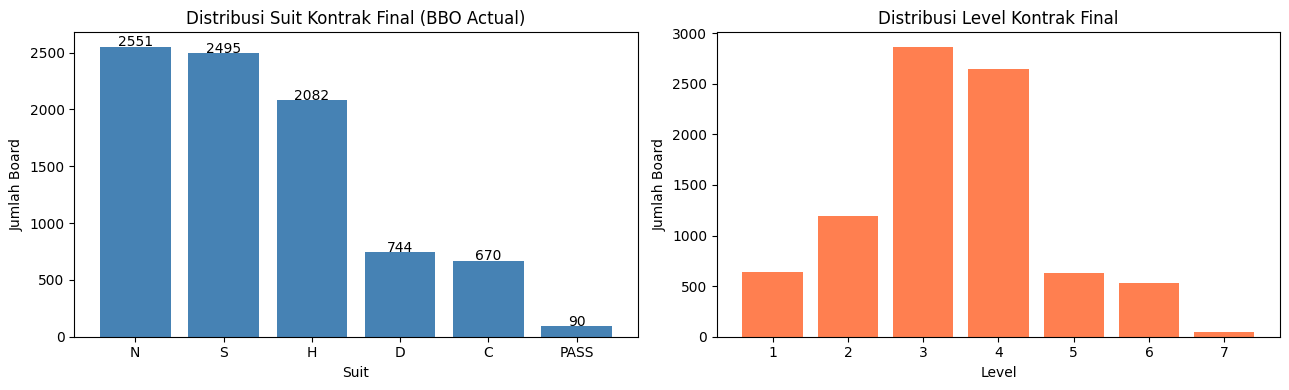

Grafik disimpan ke results/figures/


In [3]:
def get_suit(contract):
    if contract == "PASSOUT":
        return "PASS"
    m = re.match(r"[1-7]([CDHSN]|NT)", str(contract))
    return m.group(1) if m else "OTHER"

def get_level(contract):
    if contract == "PASSOUT":
        return 0
    m = re.match(r"([1-7])", str(contract))
    return int(m.group(1)) if m else -1

df_parsed["contract_suit"]  = df_parsed["final_contract"].apply(get_suit)
df_parsed["contract_level"] = df_parsed["final_contract"].apply(get_level)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

suit_counts = df_parsed["contract_suit"].value_counts()
axes[0].bar(suit_counts.index, suit_counts.values, color="steelblue")
axes[0].set_title("Distribusi Suit Kontrak Final (BBO Actual)")
axes[0].set_xlabel("Suit")
axes[0].set_ylabel("Jumlah Board")
for i, (k, v) in enumerate(suit_counts.items()):
    axes[0].text(i, v + 5, str(v), ha="center")

level_counts = df_parsed["contract_level"][df_parsed["contract_level"] > 0].value_counts().sort_index()
axes[1].bar(level_counts.index, level_counts.values, color="coral")
axes[1].set_title("Distribusi Level Kontrak Final")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Jumlah Board")

plt.tight_layout()
plt.savefig(RESULTS / "figures" / "eda_contract_distribution.png", dpi=150)
plt.show()
print("Grafik disimpan ke results/figures/")

## 2.2 Distribusi Panjang Bidding Sequence

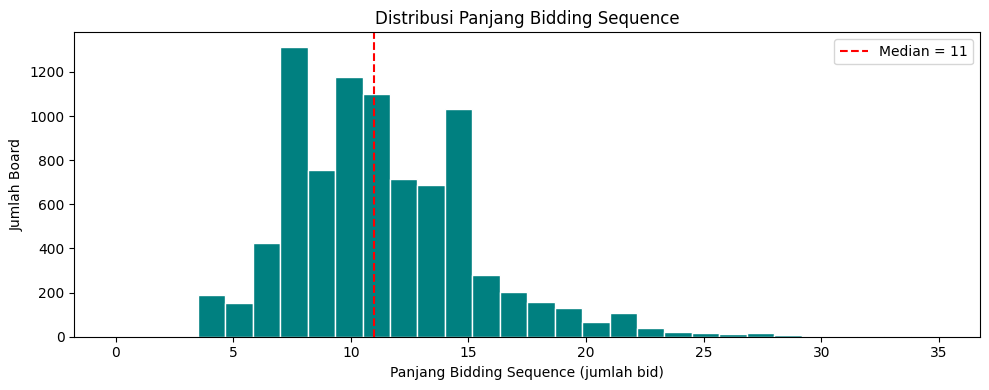

Rata-rata panjang bidding: 11.3 bid
Median panjang bidding  : 11 bid


In [4]:
df_parsed["bid_length"] = df_parsed["bidding_sequence"].apply(
    lambda x: len(str(x).split()) if pd.notna(x) and str(x).strip() else 0
)

plt.figure(figsize=(10, 4))
plt.hist(df_parsed["bid_length"], bins=30, color="teal", edgecolor="white")
plt.xlabel("Panjang Bidding Sequence (jumlah bid)")
plt.ylabel("Jumlah Board")
plt.title("Distribusi Panjang Bidding Sequence")
plt.axvline(df_parsed["bid_length"].median(), color="red", linestyle="--",
            label=f'Median = {df_parsed["bid_length"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "figures" / "eda_bid_length.png", dpi=150)
plt.show()
print(f"Rata-rata panjang bidding: {df_parsed['bid_length'].mean():.1f} bid")
print(f"Median panjang bidding  : {df_parsed['bid_length'].median():.0f} bid")

## 2.3 Kualitas Data

In [5]:
print("=== Kualitas Data ===")
print(f"Total record          : {len(df_parsed)}")
print(f"Duplikat board        : {df_parsed.duplicated(subset=['source_file','board_number','room']).sum()}")
print(f"Missing north_hand    : {df_parsed['north_hand_norm'].isna().sum()}")
print(f"Missing south_hand    : {df_parsed['south_hand_norm'].isna().sum()}")
print(f"Missing bidding_seq   : {(df_parsed['bidding_sequence'].isna() | (df_parsed['bidding_sequence'] == '')).sum()}")
print(f"Pass-out boards       : {(df_parsed['final_contract'] == 'PASSOUT').sum()}")
print()
print("Missing values per kolom:")
missing = df_parsed.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "  Tidak ada missing values")

=== Kualitas Data ===
Total record          : 8632
Duplikat board        : 0
Missing north_hand    : 7
Missing south_hand    : 7
Missing bidding_seq   : 1
Pass-out boards       : 90

Missing values per kolom:
dealer_code            7
dealer                 7
south_hand_raw         7
west_hand_raw          7
north_hand_raw         7
east_hand_raw       1636
south_hand_norm        7
west_hand_norm         7
north_hand_norm        7
east_hand_norm      1636
tricks_claimed      1520
bidding_sequence       1


## 2.4 Distribusi Vulnerability dan Dealer

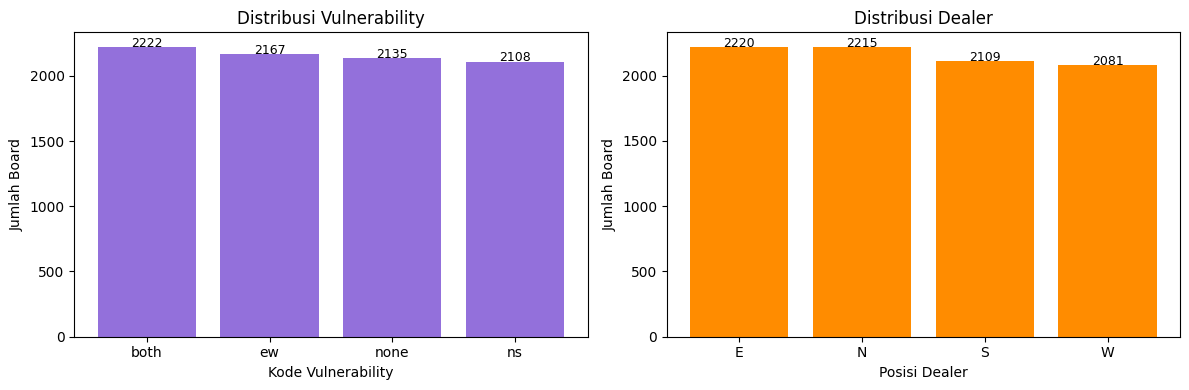

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vuln_counts = df_parsed["vulnerability"].value_counts()
axes[0].bar(vuln_counts.index, vuln_counts.values, color="mediumpurple")
axes[0].set_title("Distribusi Vulnerability")
axes[0].set_xlabel("Kode Vulnerability")
axes[0].set_ylabel("Jumlah Board")
for i, (k, v) in enumerate(vuln_counts.items()):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=9)

dealer_counts = df_parsed["dealer"].value_counts()
axes[1].bar(dealer_counts.index, dealer_counts.values, color="darkorange")
axes[1].set_title("Distribusi Dealer")
axes[1].set_xlabel("Posisi Dealer")
axes[1].set_ylabel("Jumlah Board")
for i, (k, v) in enumerate(dealer_counts.items()):
    axes[1].text(i, v + 2, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / "figures" / "eda_vuln_dealer.png", dpi=150)
plt.show()

## 2.5 Open Room vs Closed Room

Parser menghasilkan 2 record per board: open room dan closed room.
Untuk training model, kita hanya perlu satu (dideduplikasi di Step 4).

In [7]:
if "room" in df_parsed.columns:
    room_counts = df_parsed["room"].value_counts()
    print("Distribusi room:")
    print(room_counts.to_string())
    print(f"\nUnik board (source_file + board_number): "
          f"{df_parsed.groupby(['source_file','board_number']).ngroups}")
else:
    print("Kolom 'room' tidak ada")

Distribusi room:
room
open      4326
closed    4306

Unik board (source_file + board_number): 4489


---
## Output

Grafik yang dihasilkan:
- `results/figures/eda_contract_distribution.png`
- `results/figures/eda_bid_length.png`
- `results/figures/eda_vuln_dealer.png`

**Langkah berikutnya:** Buka `03_features.ipynb` untuk ekstraksi fitur.